**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# Load data (NHL goalies)
url = "https://raw.githubusercontent.com/maddieemert/week_8/refs/heads/main/GOALIES.csv"
df = pd.read_csv(url)

df.head()

,name,first,last,games,started,wins,losses,conceded,saves,minutes,goals,assists,active,hof
0,George Abbott,1944,1944,1,NaN,0.0,1.0,7,NaN,60,0,0,False,False
1,John Adams,1973,1975,22,NaN,9.0,10.0,85,605.0,1180,0,0,False,False
2,David Aebischer,2001,2008,214,1.0,106.0,74.0,513,5294.0,12230,0,5,False,False
3,John Aiken,1958,1958,1,NaN,0.0,1.0,6,12.0,34,0,0,False,False
4,Andy Aitkenhead,1933,1935,106,NaN,47.0,43.0,257,NaN,6570,0,0,False,False


In [63]:
# Clean data
# Keep only necessary columns
df = df[['name', 'wins', 'games', 'saves', 'conceded', 'hof']].copy()

# Convert categorical boolean to numeric
df['hof'] = df['hof'].astype(int)

# Ensure numeric columns are numeric
numeric_cols = ['wins', 'games', 'saves', 'conceded']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Handle missing values
df.dropna(subset=['wins'], inplace=True)    # drop rows missing target variable
df.dropna(subset=['saves'], inplace=True)   # drop players with missing saves

# Drop goalies with fewer than 50 games
df = df[df['games'] >= 50].copy()

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Check results
df.info()
df.head()

# Target/outcome variable: wins
# Features/predictors: games, saves, conceded, hof

<class 'pandas.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      404 non-null    str    
 1   wins      404 non-null    float64
 2   games     404 non-null    int64  
 3   saves     404 non-null    float64
 4   conceded  404 non-null    int64  
 5   hof       404 non-null    int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 19.1 KB


,name,wins,games,saves,conceded,hof
0,David Aebischer,106.0,214,5294.0,513,0
1,Jake Allen,208.0,460,11671.0,1191,0
2,Frederik Andersen,308.0,517,13734.0,1273,0
3,Craig Anderson,319.0,709,19846.0,1916,0
4,Justus Annunen,25.0,52,1188.0,139,0


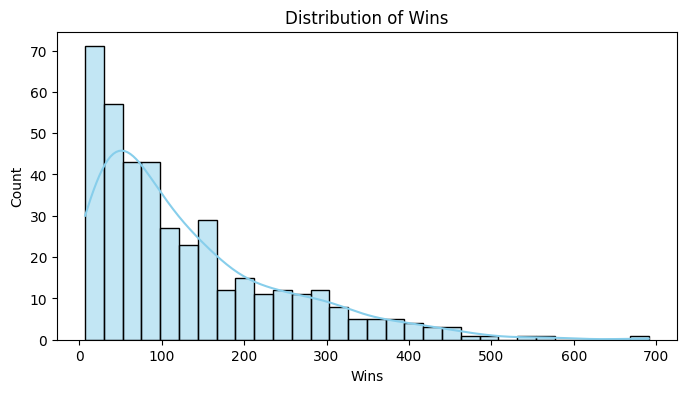

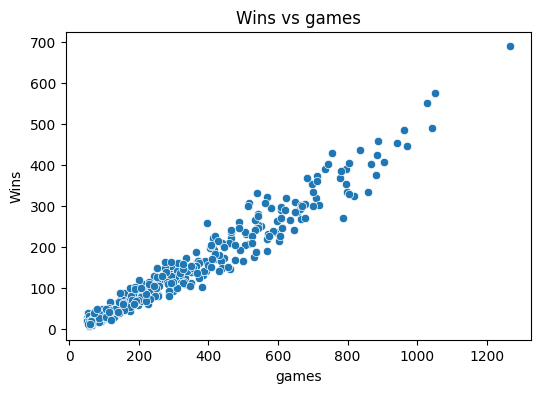

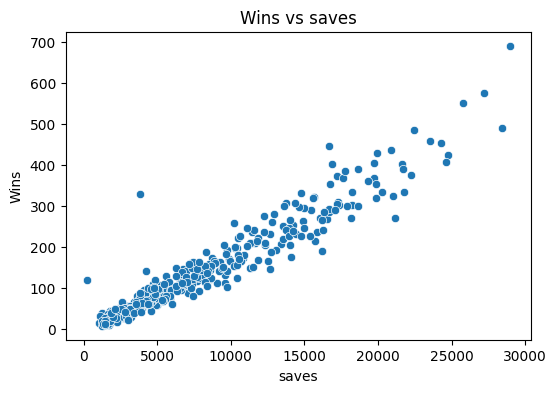

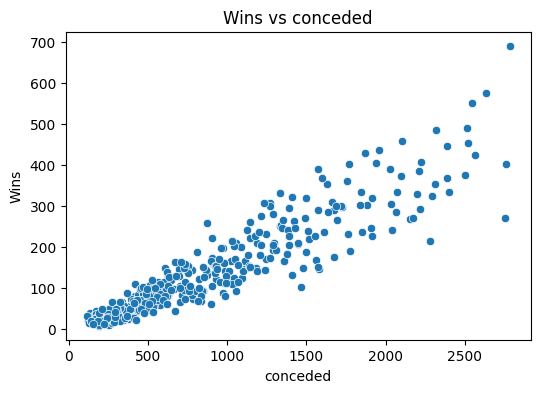

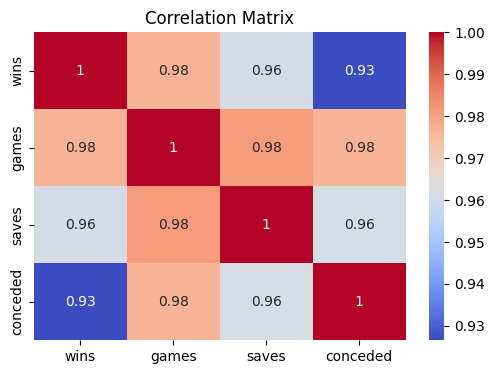

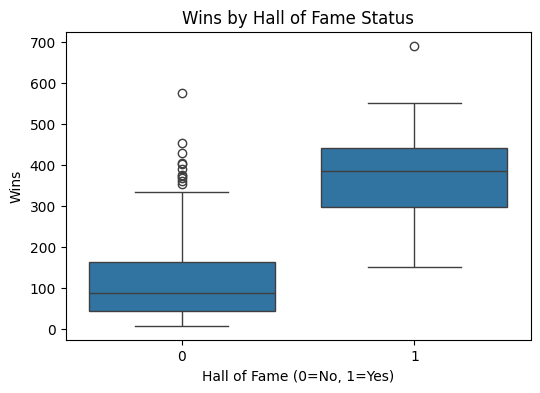

In [64]:
# Exploratory Data Analysis
# Distribution of the target variable (wins)
plt.figure(figsize=(8,4))
sns.histplot(df['wins'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Wins")
plt.xlabel("Wins")
plt.ylabel("Count")
plt.show()

# Scatterplots: numeric predictors vs target
numeric_preds = ['games', 'saves', 'conceded']
for col in numeric_preds:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='wins')
    plt.title(f"Wins vs {col}")
    plt.xlabel(col)
    plt.ylabel("Wins")
    plt.show()

# Correlation matrix (numeric variables)
plt.figure(figsize=(6,4))
sns.heatmap(df[['wins','games','saves','conceded']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Boxplot: wins by HOF status
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='hof', y='wins')
plt.title("Wins by Hall of Fame Status")
plt.xlabel("Hall of Fame (0=No, 1=Yes)")
plt.ylabel("Wins")
plt.show()

In [65]:
# Train/test split
# Define target and predictors
X = df[['games', 'saves', 'conceded', 'hof']]   # features/predictors
y = df['wins']                                  # target/outcome variable

# Split dataset: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# Run regressions
# Function to fit model and compute RMSE
def run_regression(X_train, X_test, y_train, y_test, model_name):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{model_name} RMSE on test set: {rmse:.2f}")
    return model, rmse

# Model 1: wins ~ games
X_train_m1 = X_train[['games']]
X_test_m1 = X_test[['games']]
model1, rmse1 = run_regression(X_train_m1, X_test_m1, y_train, y_test, "Model 1 (games only)")

# Model 2: wins ~ games + saves
X_train_m2a = X_train[['games','saves']]
X_test_m2a = X_test[['games','saves']]
model2a, rmse2a = run_regression(X_train_m2a, X_test_m2a, y_train, y_test, "Model 2 (games + saves)")

# Model 3: wins ~ games + saves + conceded
X_train_m2b = X_train[['games','saves','conceded']]
X_test_m2b = X_test[['games','saves','conceded']]
model2b, rmse2b = run_regression(X_train_m2b, X_test_m2b, y_train, y_test, "Model 3 (games + saves + conceded)")

# Model 4: wins ~ games + saves + conceded + hof
X_train_m3 = X_train[['games','saves','conceded','hof']]
X_test_m3 = X_test[['games','saves','conceded','hof']]
model3, rmse3 = run_regression(X_train_m3, X_test_m3, y_train, y_test, "Model 4 (all predictors)")

Model 1 (games only) RMSE on test set: 28.00
Model 2 (games + saves) RMSE on test set: 27.89
Model 3 (games + saves + conceded) RMSE on test set: 23.13
Model 4 (all predictors) RMSE on test set: 22.69


Model 4 performed the best (all predictors: games + saves + conceded + hof). This is because it had the lowest RMSE (22.69), meaning its predictions are closer to the actual number of wins. It also combines all meaningful predictors, allowing for better predictions based on a wider set of data.

From this assignment, I learned that goalie wins are strongly influenced by performance metrics such as saves on top of the number of games played. I also learned about the significance of incremental modeling, which helps identify feature importance. By gradually adding predictors, I saw the accuracy of the model increase. Additionally, I learned the importance of data cleaning, as my dataset originally contained several outliers and null values that would've thrown off my model. Overall, I learned that a combination of opportunity/longevity (games), performance (saves & conceded), and recognition (hof) best explains an NHL goalie's wins, and the best way to test that in a linear regression model is by combining them all.